# STA/LTA golden-dataset explorer

Use this notebook to visually inspect every candidate event in `events.yaml`,
verify that the seismograms look as expected, adjust STA/LTA parameters, and
export the per-event ground-truth annotations that seed the private golden
dataset.

**Workflow**
1. Run cells top-to-bottom once to load everything.
2. In *Section 3*, step through each event with the loop — look at the figure.
3. If a window is wrong, tweak `window_min`, `pre_filt`, or `stalta_params` in
   the event's YAML entry and re-run that cell.
4. In *Section 4*, run the annotation helper — it saves one YAML file per
   event under `goldens/annotations/`.
5. Commit the annotation files (but **not** the raw waveforms) to the private
   golden directory or your local `FM_STALTA_GOLDEN_DIR`.

> **Requirement** — runs in the `full` Pixi environment:
> ```bash
> pixi run -e full jupyter lab notebooks/
> ```

In [1]:
# ── imports ────────────────────────────────────────────────────────────────
import sys
from pathlib import Path

# Ensure the src tree is importable even if the package is not installed.
REPO_ROOT = Path(".").resolve().parent
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

import json
import warnings
from datetime import datetime, timezone, timedelta

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yaml

matplotlib.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

try:
    from obspy import UTCDateTime
    from obspy.clients.fdsn import Client
    from obspy.signal.trigger import classic_sta_lta, trigger_onset
    OBSPY_OK = True
    print("ObsPy OK")
except ImportError:
    OBSPY_OK = False
    print("⚠  ObsPy not found — waveform cells will be skipped. "
          "Run: pixi run -e full jupyter lab notebooks/")

print(f"Repo root: {REPO_ROOT}")

ObsPy OK
Repo root: /Users/marinedenolle/GitHub/frugalmind


## 1 — Load events from `events.yaml`

In [2]:
EVENTS_YAML = REPO_ROOT / "src" / "repere_suites" / "sta_lta" / "events.yaml"

with open(EVENTS_YAML) as f:
    _data = yaml.safe_load(f)

EVENTS = _data["events"]

print(f"Loaded {len(EVENTS)} events:")
for ev in EVENTS:
    flag = "✅" if ev["expected_detection"] else "⬛"
    verify = "  ⚠ NEEDS VERIFY" if "VERIFY" in ev["id"] else ""
    print(f"  {flag}  [{ev['split']:10s}]  {ev['id']:45s}  {ev['label']}{verify}")

Loaded 6 events:
  ✅  [validation]  nisqually-2001                                 M6.8 Nisqually deep intraslab earthquake
  ✅  [validation]  tohoku-2011-teleseism                          M9.1 Tōhoku, recorded as teleseism in PNW
  ✅  [test      ]  mt-rainier-swarm-2026                          Mt. Rainier shallow swarm, 2025
  ⬛  [test      ]  pnsn-quiet-day-VERIFY                          Quiet day on UW.LON — no events expected  ⚠ NEEDS VERIFY
  ✅  [test      ]  cascade-quarry-blast-VERIFY                    Routine quarry blast flagged in PNSN catalog (placeholder)  ⚠ NEEDS VERIFY
  ✅  [test      ]  low-lf-volcano-snr                             Low-SNR LF volcanic event near detection threshold at Mt St Helens


## 2 — Helper functions

In [3]:
# Default FDSN client — IRIS works for all UW/BK/IU/II stations.
# If you have a regional mirror, set FDSN_URL below.
FDSN_URL = "IRIS"


def fetch_waveform(event: dict, client: "Client") -> "obspy.Stream | None":
    """Download waveform for the first recommended station of an event.

    Returns an ObsPy Stream, or None when the download fails.
    """
    sta_cfg = event["recommended_stations"][0]
    t0 = UTCDateTime(event["origin_time"])
    hw = event["suggested_window_min"] * 60 / 2
    t_start = t0 - hw
    t_end   = t0 + hw
    net = sta_cfg["network"]
    sta = sta_cfg["station"]
    loc = sta_cfg["location"] or "*"
    cha = sta_cfg["channel"]

    print(f"  Fetching {net}.{sta}.{loc}.{cha}  "
          f"{t_start.strftime('%Y-%m-%dT%H:%M:%S')} – {t_end.strftime('%H:%M:%S')} UTC …",
          end=" ")
    try:
        st = client.get_waveforms(net, sta, loc, cha, t_start, t_end)
        print(f"OK ({len(st)} trace(s))")
        return st
    except Exception as exc:
        print(f"FAILED — {exc}")
        return None


# Canonical filter bands per source category (from recipe.py)
_FILTER = {
    "regional_earthquake": (1.0, 20.0),
    "teleseism":           (0.02, 0.5),
    "noise_day":           (1.0, 20.0),
    "quarry_blast":        (1.0, 20.0),
    "volcanic_lp":         (0.5, 5.0),
}


def preprocess(st: "obspy.Stream", event: dict) -> "obspy.Trace":
    """Merge, trim, detrend, taper, bandpass-filter. Returns the first trace."""
    from obspy import UTCDateTime
    st = st.copy()
    st.merge(fill_value="interpolate")
    t0 = UTCDateTime(event["origin_time"])
    hw = event["suggested_window_min"] * 60 / 2
    st.trim(t0 - hw, t0 + hw)
    st.detrend("demean")
    st.detrend("linear")
    st.taper(max_percentage=0.05, type="cosine")
    lo, hi = _FILTER.get(event["category"], (1.0, 20.0))
    st.filter("bandpass", freqmin=lo, freqmax=hi, corners=4, zerophase=True)
    return st[0]


def compute_stalta(tr: "obspy.Trace", event: dict) -> tuple:
    """Return (cft, trigger_list) using the event's stalta_params."""
    p = event["stalta_params"]
    df = tr.stats.sampling_rate
    cft = classic_sta_lta(tr.data, int(p["sta"] * df), int(p["lta"] * df))
    triggers = trigger_onset(cft, p["on_thresh"], p["off_thresh"])
    return cft, triggers


def plot_event(
    tr: "obspy.Trace",
    cft: np.ndarray,
    triggers,
    event: dict,
    *,
    figsize: tuple = (13, 6),
) -> plt.Figure:
    """Two-panel plot: waveform (top) + STA/LTA characteristic function (bottom).
    Trigger onsets are shown as red vertical lines, offsets as blue.
    """
    from obspy import UTCDateTime
    p     = event["stalta_params"]
    df    = tr.stats.sampling_rate
    t_abs = [tr.stats.starttime.datetime + timedelta(seconds=i / df)
             for i in range(len(tr.data))]
    origin = UTCDateTime(event["origin_time"]).datetime.replace(tzinfo=timezone.utc)

    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=figsize)

    ax1.plot(t_abs, tr.data, color="k", linewidth=0.5)
    ax1.axvline(origin, color="crimson", linewidth=1.2, label="catalog origin")
    ax1.set_ylabel("Counts")
    ax1.legend(loc="upper right", fontsize=8)
    title = (f"{tr.id}   |   {event['label']}\n"
             f"category={event['category']}   split={event['split']}   "
             f"expected_detection={event['expected_detection']}")
    ax1.set_title(title, fontsize=9)

    ax2.plot(t_abs, cft, color="navy", linewidth=0.6)
    ax2.axhline(p["on_thresh"],  color="firebrick", linestyle="--",
                linewidth=0.8, label=f"on  = {p['on_thresh']}")
    ax2.axhline(p["off_thresh"], color="steelblue",  linestyle=":",
                linewidth=0.8, label=f"off = {p['off_thresh']}")

    trigger_times = []
    for on_idx, off_idx in triggers:
        t_on  = t_abs[min(on_idx,  len(t_abs) - 1)]
        t_off = t_abs[min(off_idx, len(t_abs) - 1)]
        ax2.axvline(t_on,  color="red",   linewidth=1.0, alpha=0.8)
        ax2.axvline(t_off, color="blue",  linewidth=1.0, alpha=0.5)
        # convert to UTC-aware datetime
        t_on_utc = (tr.stats.starttime + on_idx / df).datetime.replace(tzinfo=timezone.utc)
        trigger_times.append(t_on_utc.isoformat(timespec="seconds"))

    ax2.axvline(origin, color="crimson", linewidth=1.2)
    ax2.set_xlabel("UTC time")
    ax2.set_ylabel("STA/LTA")
    ax2.legend(loc="upper right", fontsize=8)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
    fig.autofmt_xdate()
    plt.tight_layout()

    n_trig = len(triggers)
    print(f"  → {n_trig} trigger(s) detected; onset(s): {trigger_times or 'none'}")
    return fig, trigger_times

## 3 — Iterate over all events

This cell fetches + plots every event one at a time.  
You can also run just a single event by changing `EVENT_ID` in the next cell.

> Data are **not** cached by default. Re-running the cell re-downloads.  
> To cache, set `CACHE_DIR` to a local path.

In [4]:
# ── Optional waveform cache  (set to None to disable) ──────────────────────
CACHE_DIR = REPO_ROOT / ".waveform_cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)


def _cache_path(event: dict) -> Path:
    """Local mseed path for caching the raw download."""
    sta = event["recommended_stations"][0]
    name = f"{event['id']}__{sta['network']}.{sta['station']}.{sta['channel']}.mseed"
    return CACHE_DIR / name


def load_or_fetch(event: dict, client: "Client") -> "obspy.Stream | None":
    """Return cached stream if present, otherwise fetch and save."""
    from obspy import read as obspy_read
    cp = _cache_path(event)
    if cp.exists():
        print(f"  [cache] {cp.name}")
        return obspy_read(str(cp))
    st = fetch_waveform(event, client)
    if st is not None and CACHE_DIR is not None:
        st.write(str(cp), format="MSEED")
    return st


print(f"Cache dir: {CACHE_DIR}")
print("(Delete .waveform_cache/ to force a fresh download.)")

Cache dir: /Users/marinedenolle/GitHub/frugalmind/.waveform_cache
(Delete .waveform_cache/ to force a fresh download.)


/Users/marinedenolle/GitHub/frugalmind/.venv/lib/python3.14/site-packages/obspy/clients/fdsn/client.py:251: ObsPyDeprecationWarning: IRIS is now EarthScope, please consider changing the FDSN client short URL to 'EARTHSCOPE'.
  warnings.warn(msg, ObsPyDeprecationWarning)



──────────────────────────────────────────────────────────────────────
Event: nisqually-2001
  label    : M6.8 Nisqually deep intraslab earthquake
  category : regional_earthquake
  origin   : 2001-02-28T18:54:32.8
  split    : validation  |  visibility: public
  [cache] nisqually-2001__UW.LAWT.ENZ.mseed
  → 1 trigger(s) detected; onset(s): ['2001-02-28T18:54:45+00:00']


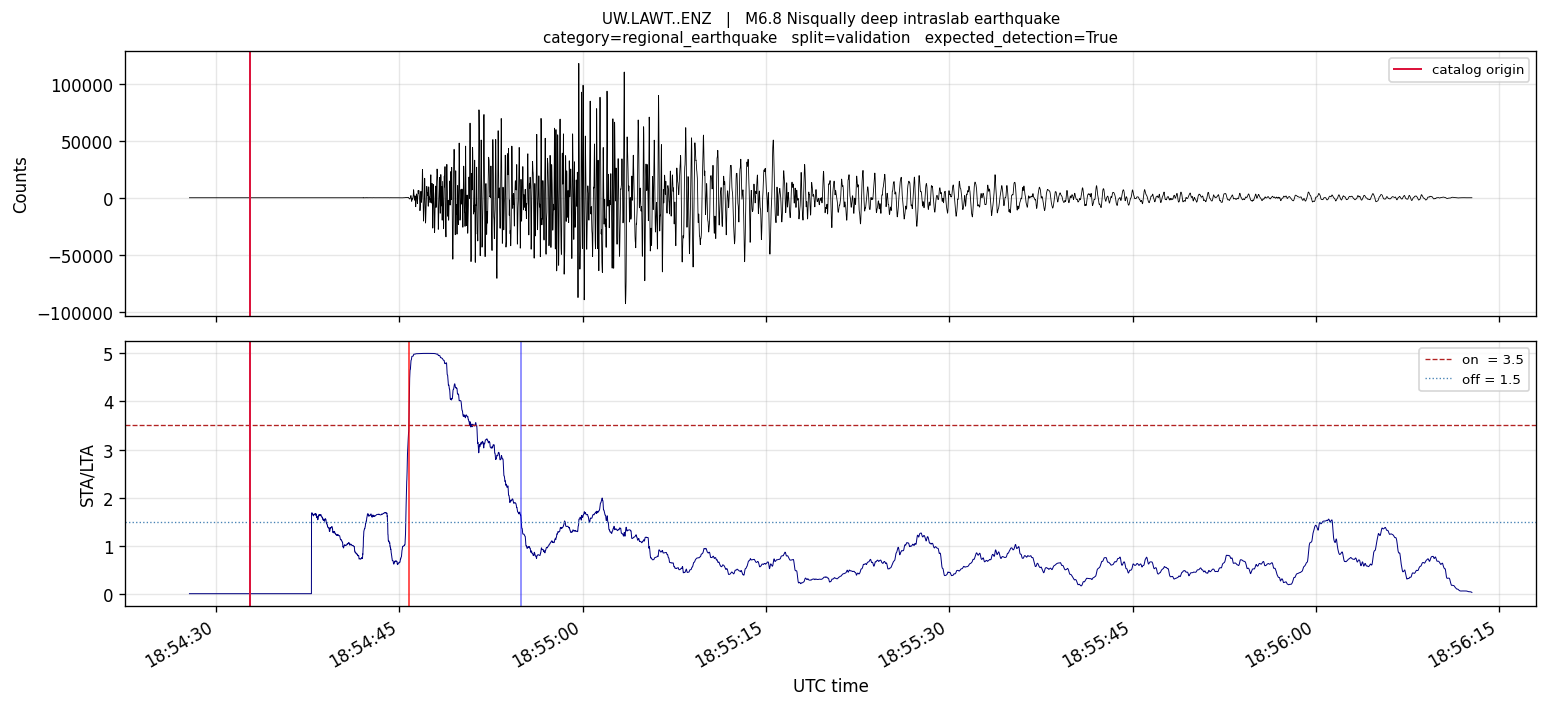


──────────────────────────────────────────────────────────────────────
Event: tohoku-2011-teleseism
  label    : M9.1 Tōhoku, recorded as teleseism in PNW
  category : teleseism
  origin   : 2011-03-11T05:46:24.0
  split    : validation  |  visibility: public
  [cache] tohoku-2011-teleseism__UW.LON.BHZ.mseed
  → 30 trigger(s) detected; onset(s): ['2011-03-11T05:17:23+00:00', '2011-03-11T05:17:41+00:00', '2011-03-11T05:18:25+00:00', '2011-03-11T05:18:51+00:00', '2011-03-11T05:19:31+00:00', '2011-03-11T05:21:12+00:00', '2011-03-11T05:22:34+00:00', '2011-03-11T05:23:26+00:00', '2011-03-11T05:25:57+00:00', '2011-03-11T05:26:45+00:00', '2011-03-11T05:29:30+00:00', '2011-03-11T05:30:49+00:00', '2011-03-11T05:42:32+00:00', '2011-03-11T05:43:06+00:00', '2011-03-11T05:44:10+00:00', '2011-03-11T05:45:14+00:00', '2011-03-11T05:46:54+00:00', '2011-03-11T05:47:03+00:00', '2011-03-11T05:49:23+00:00', '2011-03-11T05:53:23+00:00', '2011-03-11T05:57:20+00:00', '2011-03-11T05:57:59+00:00', '2011-03-11T

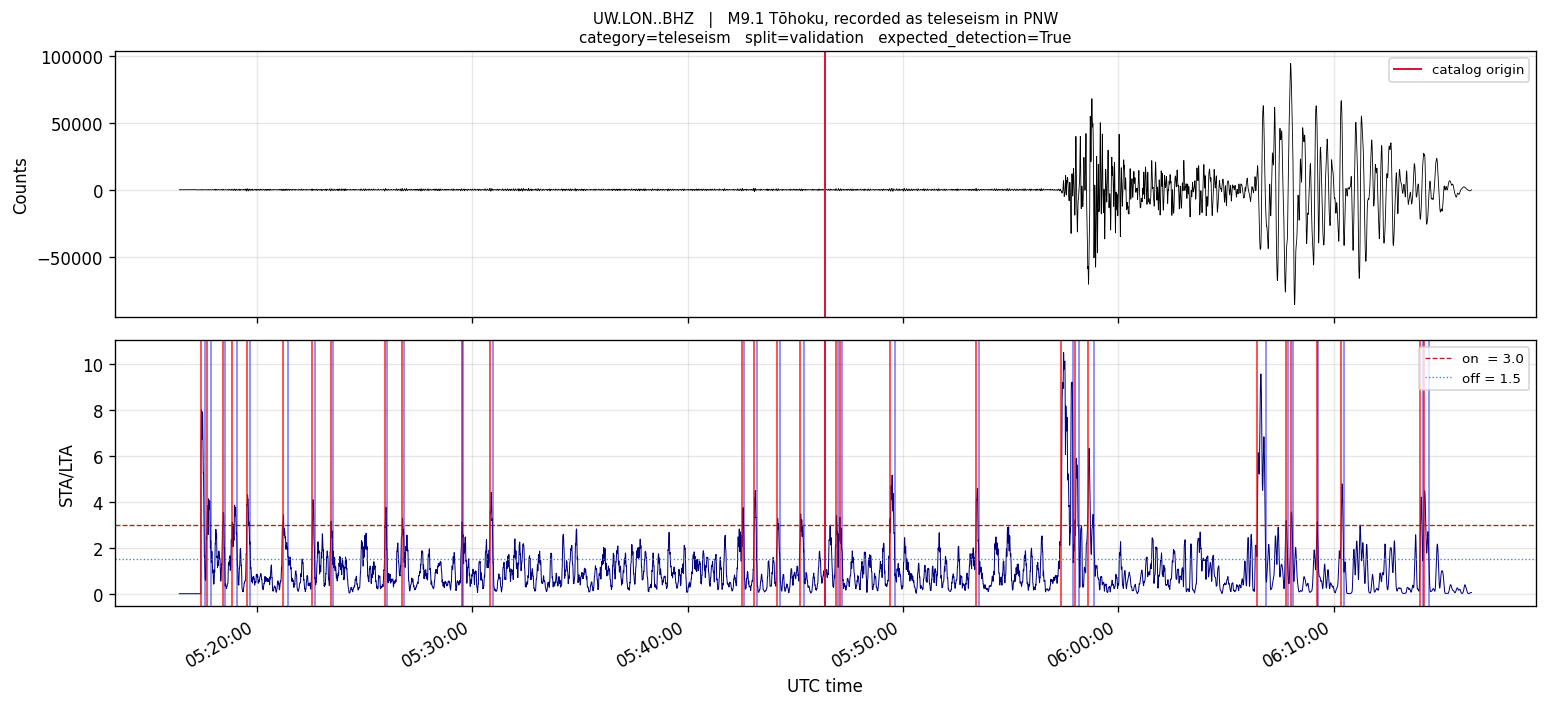


──────────────────────────────────────────────────────────────────────
Event: mt-rainier-swarm-2026
  label    : Mt. Rainier shallow swarm, 2025
  category : local_earthquake
  origin   : 2025-07-11T21:23:04+02:00
  split    : test  |  visibility: private
  [cache] mt-rainier-swarm-2026__UW.STAR.EHZ.mseed
  → 11 trigger(s) detected; onset(s): ['2025-07-11T19:20:41+00:00', '2025-07-11T19:21:26+00:00', '2025-07-11T19:21:33+00:00', '2025-07-11T19:22:14+00:00', '2025-07-11T19:22:40+00:00', '2025-07-11T19:23:04+00:00', '2025-07-11T19:23:57+00:00', '2025-07-11T19:24:20+00:00', '2025-07-11T19:24:47+00:00', '2025-07-11T19:25:07+00:00', '2025-07-11T19:25:22+00:00']


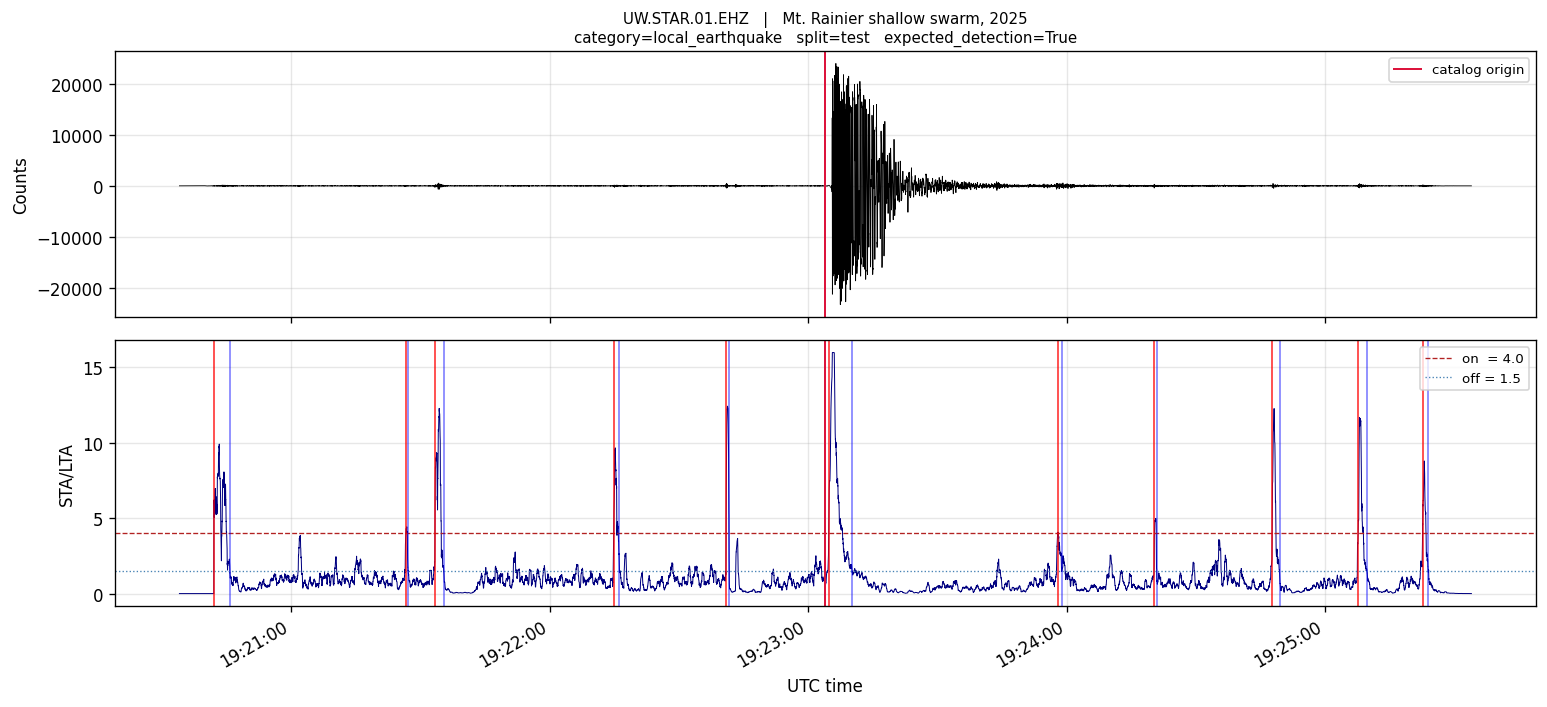


──────────────────────────────────────────────────────────────────────
Event: pnsn-quiet-day-VERIFY
  label    : Quiet day on UW.LON — no events expected
  category : noise_day
  origin   : 2026-05-09T03:00:00.0
  split    : test  |  visibility: private
  Fetching UW.LO2.*.BHZ  2026-05-09T02:45:00 – 03:15:00 UTC … FAILED — No data available for request.
HTTP Status code: 204
Detailed response of server:



──────────────────────────────────────────────────────────────────────
Event: cascade-quarry-blast-VERIFY
  label    : Routine quarry blast flagged in PNSN catalog (placeholder)
  category : quarry_blast
  origin   : 2003-11-07T23:46:0.0
  split    : test  |  visibility: private
  [cache] cascade-quarry-blast-VERIFY__UW.LCW.EHZ.mseed
  → 4 trigger(s) detected; onset(s): ['2003-11-07T23:44:36+00:00', '2003-11-07T23:44:40+00:00', '2003-11-07T23:44:49+00:00', '2003-11-07T23:46:18+00:00']


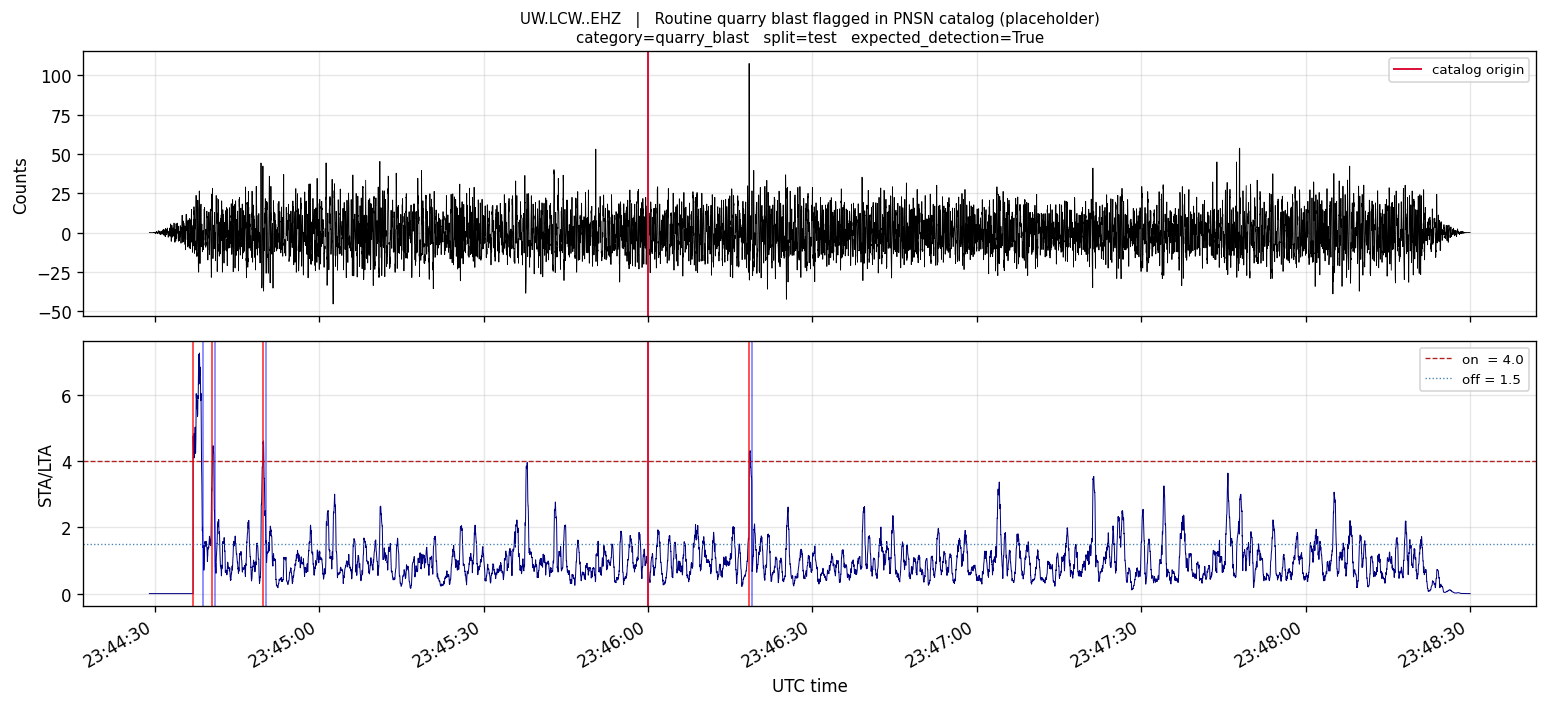


──────────────────────────────────────────────────────────────────────
Event: low-lf-volcano-snr
  label    : Low-SNR LF volcanic event near detection threshold at Mt St Helens
  category : volcanic_earthquake
  origin   : 2025/09/01 02:27:48
  split    : test  |  visibility: private
  Fetching CC.SUG.*.BHZ  2025-09-01T02:25:18 – 02:30:18 UTC … OK (1 trace(s))
  → 2 trigger(s) detected; onset(s): ['2025-09-01T02:25:25+00:00', '2025-09-01T02:27:54+00:00']


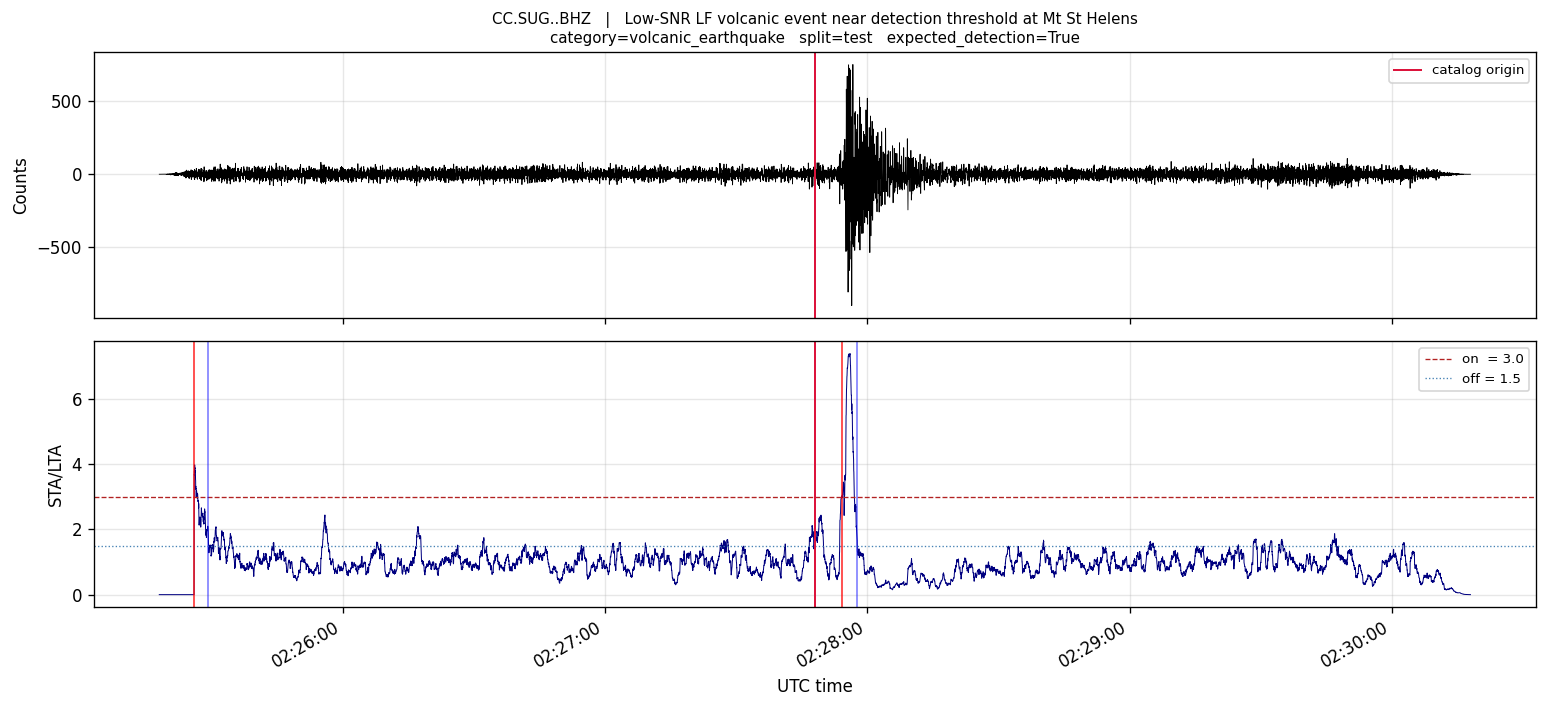


──────────────────────────────────────────────────────────────────────
Done. 5 / 6 events processed.


In [5]:
# ── Loop over ALL events ────────────────────────────────────────────────────
# Results accumulate in `RESULTS` so Section 4 can write the goldens.
RESULTS = {}   # event_id -> annotation dict

if not OBSPY_OK:
    print("Skipping — ObsPy not available.")
else:
    client = Client(FDSN_URL)
    for ev in EVENTS:
        print(f"\n{'─'*70}")
        print(f"Event: {ev['id']}")
        print(f"  label    : {ev['label']}")
        print(f"  category : {ev['category']}")
        print(f"  origin   : {ev['origin_time']}")
        print(f"  split    : {ev['split']}  |  visibility: {ev['visibility']}")

        st = load_or_fetch(ev, client)
        if st is None:
            RESULTS[ev["id"]] = {"status": "fetch_failed"}
            continue

        tr  = preprocess(st, ev)
        cft, triggers = compute_stalta(tr, ev)
        fig, trigger_times = plot_event(tr, cft, triggers, ev)
        plt.show()

        RESULTS[ev["id"]] = {
            "event_id":          ev["id"],
            "category":          ev["category"],
            "split":             ev["split"],
            "visibility":        ev["visibility"],
            "origin_time":       ev["origin_time"],
            "expected_detection": ev["expected_detection"],
            "n_triggers":        len(triggers),
            "trigger_onset_utc": trigger_times,
            "station":           tr.id,
            "stalta_params":     ev["stalta_params"],
            "filter_band":       list(_FILTER.get(ev["category"], (1.0, 20.0))),
            "magnitude":         ev.get("magnitude"),
            "catalog_id":        ev.get("catalog_id"),
            "notes_auto":        "generated by 02_stalta_golden_explorer.ipynb",
        }

    print(f"\n{'─'*70}")
    print(f"Done. {len([r for r in RESULTS.values() if r.get('status') != 'fetch_failed'])} "
          f"/ {len(EVENTS)} events processed.")

## 3b — Single-event deep-dive

Set `EVENT_ID` to any id from the summary printed above to re-plot just that event,
with custom parameters — useful for tuning thresholds before writing the golden.

  [cache] nisqually-2001__UW.LAWT.ENZ.mseed
  → 1 trigger(s) detected; onset(s): ['2001-02-28T18:54:45+00:00']


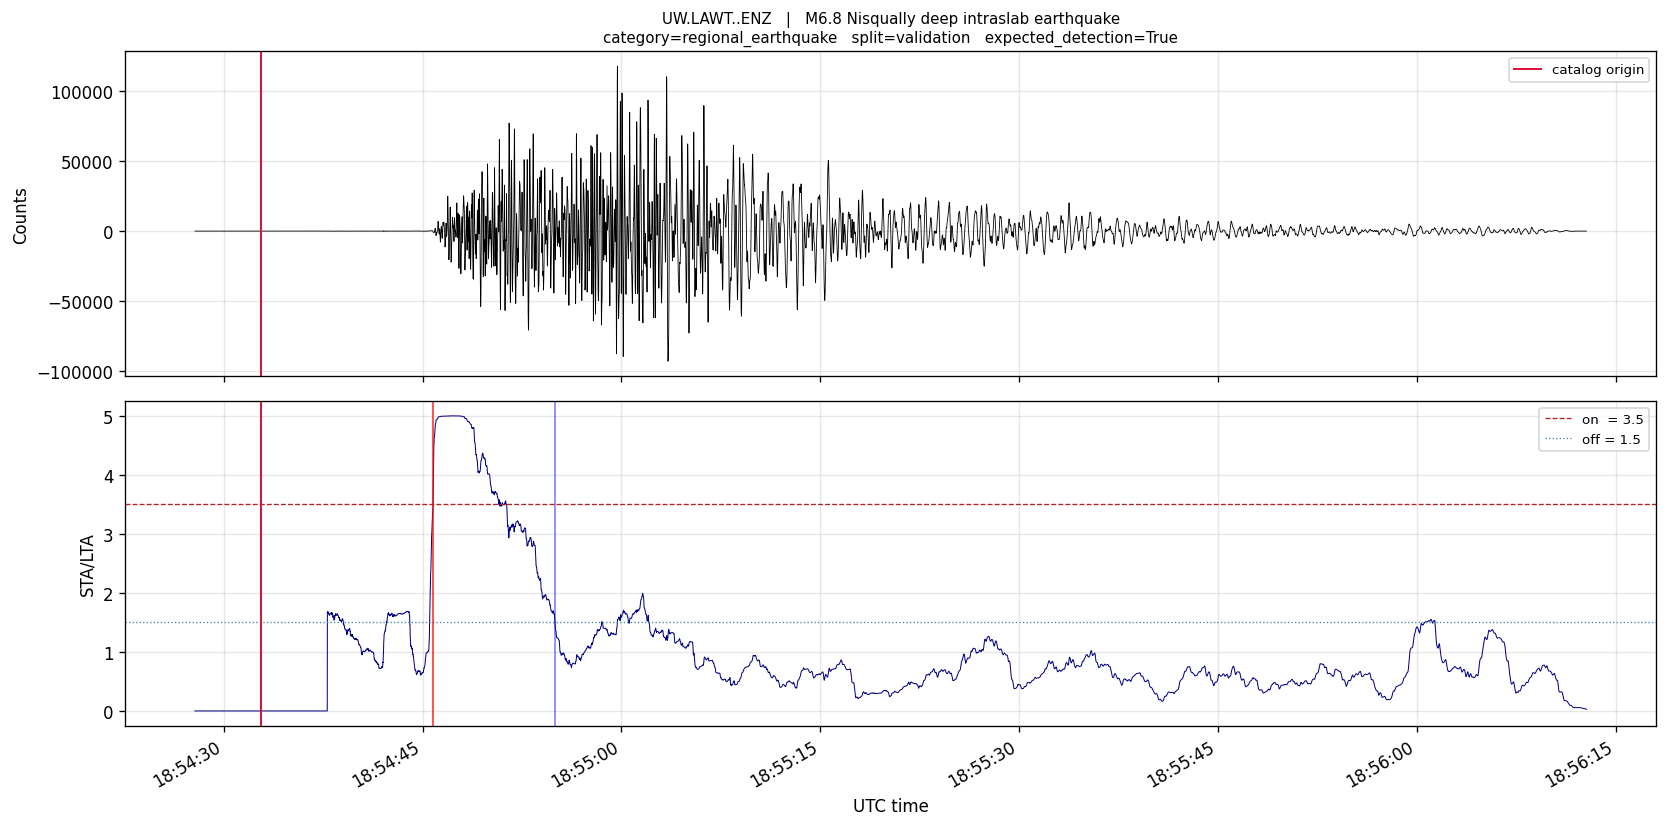


Used params: {
  "sta": 2.0,
  "lta": 10.0,
  "on_thresh": 3.5,
  "off_thresh": 1.5
}


In [6]:
EVENT_ID = "nisqually-2001"   # ← change this

# Optional overrides — set to None to use values from events.yaml
OVERRIDE_WINDOW_MIN   = None   # e.g. 20  (total window = 2× this, centred on origin)
OVERRIDE_STA          = None   # e.g. 1.5
OVERRIDE_LTA          = None   # e.g. 8.0
OVERRIDE_ON_THRESH    = None   # e.g. 4.0
OVERRIDE_OFF_THRESH   = None   # e.g. 1.5
OVERRIDE_STATION_IDX  = 0      # index into recommended_stations list

# ── execution ──────────────────────────────────────────────────────────────
if not OBSPY_OK:
    print("ObsPy not available — skipping.")
else:
    ev = next(e for e in EVENTS if e["id"] == EVENT_ID)
    ev_work = dict(ev)   # shallow copy so we don't mutate the source

    if OVERRIDE_WINDOW_MIN is not None:
        ev_work["suggested_window_min"] = OVERRIDE_WINDOW_MIN
    if any(v is not None for v in [OVERRIDE_STA, OVERRIDE_LTA,
                                    OVERRIDE_ON_THRESH, OVERRIDE_OFF_THRESH]):
        base = dict(ev_work["stalta_params"])
        if OVERRIDE_STA:        base["sta"]        = OVERRIDE_STA
        if OVERRIDE_LTA:        base["lta"]        = OVERRIDE_LTA
        if OVERRIDE_ON_THRESH:  base["on_thresh"]  = OVERRIDE_ON_THRESH
        if OVERRIDE_OFF_THRESH: base["off_thresh"] = OVERRIDE_OFF_THRESH
        ev_work["stalta_params"] = base

    # Use a potentially different station
    stations_used = ev_work["recommended_stations"][OVERRIDE_STATION_IDX:]
    ev_work["recommended_stations"] = stations_used

    client = Client(FDSN_URL)
    st = load_or_fetch(ev_work, client)
    if st is not None:
        tr  = preprocess(st, ev_work)
        cft, triggers = compute_stalta(tr, ev_work)
        fig, trigger_times = plot_event(tr, cft, triggers, ev_work, figsize=(14, 7))
        plt.show()
        print("\nUsed params:", json.dumps(ev_work["stalta_params"], indent=2))

## 4 — Multi-station panel for one event

Fetch **all** recommended stations for a single event and display them on one figure.
Good for verifying that the event is detectable network-wide, not just on one channel.

  [cache] nisqually-2001__UW.LAWT.ENZ.mseed
  Fetching UW.PCMD.*.ENZ  2001-02-28T18:47:02 – 19:02:02 UTC … OK (1 trace(s))


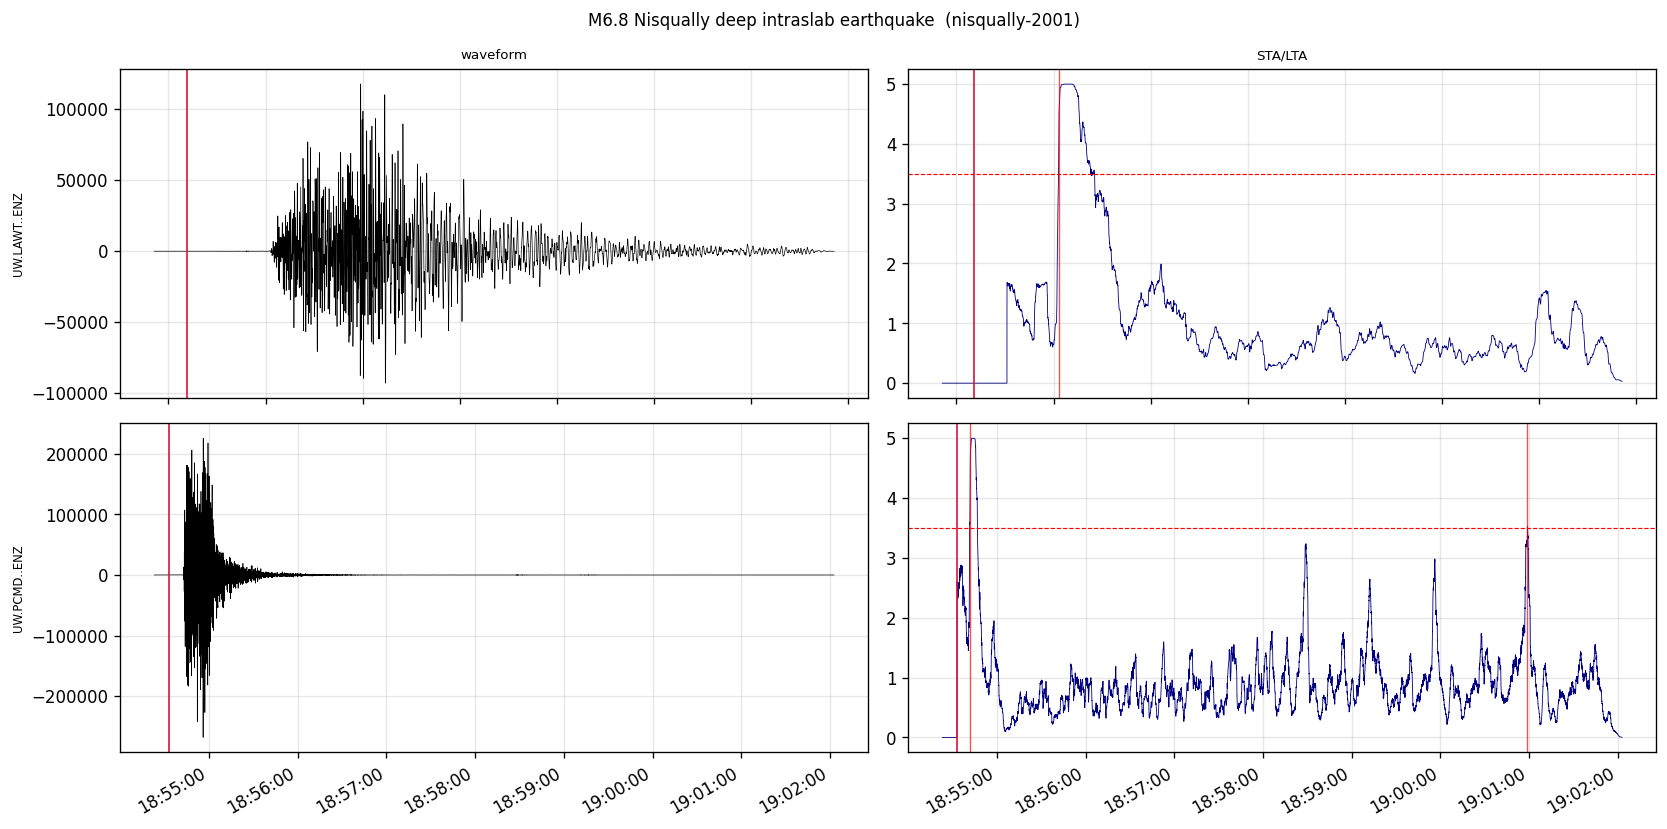

In [7]:
MULTISTATION_EVENT_ID = "nisqually-2001"   # ← change this

if not OBSPY_OK:
    print("ObsPy not available — skipping.")
else:
    from obspy import UTCDateTime

    ev = next(e for e in EVENTS if e["id"] == MULTISTATION_EVENT_ID)
    client = Client(FDSN_URL)
    n_sta = len(ev["recommended_stations"])
    fig, axes = plt.subplots(n_sta, 2, figsize=(14, 3.5 * n_sta), sharex=False)
    if n_sta == 1:
        axes = [axes]  # normalise shape

    for i, sta_cfg in enumerate(ev["recommended_stations"]):
        ev_single = dict(ev, recommended_stations=[sta_cfg])
        st = load_or_fetch(ev_single, client)
        if st is None:
            for ax in axes[i]:
                ax.set_visible(False)
            continue
        tr  = preprocess(st, ev_single)
        cft, triggers = compute_stalta(tr, ev_single)
        p  = ev["stalta_params"]
        df = tr.stats.sampling_rate
        origin = UTCDateTime(ev["origin_time"]).datetime.replace(tzinfo=timezone.utc)
        t_abs = [
            tr.stats.starttime.datetime + timedelta(seconds=k / df)
            for k in range(len(tr.data))
        ]

        ax1, ax2 = axes[i]
        ax1.plot(t_abs, tr.data, "k", linewidth=0.4)
        ax1.axvline(origin, color="crimson", linewidth=1.0)
        ax1.set_ylabel(tr.id, fontsize=7)
        ax1.set_title("waveform" if i == 0 else "", fontsize=8)

        ax2.plot(t_abs, cft, "navy", linewidth=0.5)
        ax2.axhline(p["on_thresh"],  color="r", linestyle="--", linewidth=0.7)
        ax2.axvline(origin, color="crimson", linewidth=1.0)
        for on_idx, _ in triggers:
            ax2.axvline(t_abs[min(on_idx, len(t_abs)-1)], color="red", linewidth=0.8, alpha=0.7)
        ax2.set_title("STA/LTA" if i == 0 else "", fontsize=8)
        for ax in (ax1, ax2):
            ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))

    fig.suptitle(f"{ev['label']}  ({ev['id']})", fontsize=10)
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

## 5 — Export golden annotations

After verifying the plots, run this cell to write one YAML file per event to
`goldens/annotations/`.  These files are the ground-truth the scorers compare
against — commit them to your private golden directory or to
`FM_STALTA_GOLDEN_DIR`.

For **private** events the file will be written but you should **not** commit
it to the public repo.  Add `goldens/` to `.gitignore` (already done by default).

In [8]:
GOLDENS_DIR = REPO_ROOT / "goldens" / "annotations"
GOLDENS_DIR.mkdir(parents=True, exist_ok=True)

# You can add free-text notes per event here before writing.
# Keys should match event ids.
MANUAL_NOTES = {
    # "nisqually-2001": "Very clear P and S arrivals; no need to adjust thresholds.",
}

written = []
skipped = []

for ev_id, ann in RESULTS.items():
    if ann.get("status") == "fetch_failed":
        skipped.append(ev_id)
        continue
    if ev_id in MANUAL_NOTES:
        ann["notes_manual"] = MANUAL_NOTES[ev_id]
    out = GOLDENS_DIR / f"{ev_id}.yaml"
    with open(out, "w") as fh:
        yaml.dump(ann, fh, sort_keys=False, allow_unicode=True)
    written.append(out)

print(f"Written {len(written)} annotation file(s) to {GOLDENS_DIR}/")
for p in written:
    print(f"  {p.name}")
if skipped:
    print(f"\nSkipped (fetch failed): {skipped}")
print("\n⚠  Private-visibility events should NOT be committed to the public repo.")
print("   Keep them in FM_STALTA_GOLDEN_DIR or a separate private repository.")

Written 5 annotation file(s) to /Users/marinedenolle/GitHub/frugalmind/goldens/annotations/
  nisqually-2001.yaml
  tohoku-2011-teleseism.yaml
  mt-rainier-swarm-2026.yaml
  cascade-quarry-blast-VERIFY.yaml
  low-lf-volcano-snr.yaml

Skipped (fetch failed): ['pnsn-quiet-day-VERIFY']

⚠  Private-visibility events should NOT be committed to the public repo.
   Keep them in FM_STALTA_GOLDEN_DIR or a separate private repository.


## 6 — Summary table of all results

In [9]:
import textwrap

header = f"{'id':45s} {'split':10s} {'exp':5s} {'n_trig':6s} {'onset (UTC)':30s} {'status'}"
print(header)
print("-" * len(header))

for ev in EVENTS:
    eid = ev["id"]
    ann = RESULTS.get(eid, {})
    if ann.get("status") == "fetch_failed":
        status = "FETCH FAILED"
        n_t = "-"
        onsets = "-"
    elif not ann:
        status = "not run"
        n_t = "-"
        onsets = "-"
    else:
        n_t = str(ann.get("n_triggers", 0))
        onsets_list = ann.get("trigger_onset_utc", [])
        onsets = ", ".join(onsets_list[:2]) or "none"
        if len(onsets_list) > 2:
            onsets += f" (+{len(onsets_list)-2} more)"
        detected = ann["n_triggers"] > 0
        agree = detected == ev["expected_detection"]
        status = "✅ agree" if agree else "❌ disagree"

    exp = "yes" if ev["expected_detection"] else "no"
    print(f"{eid:45s} {ev['split']:10s} {exp:5s} {n_t:6s} {onsets:30s} {status}")

id                                            split      exp   n_trig onset (UTC)                    status
-----------------------------------------------------------------------------------------------------------
nisqually-2001                                validation yes   1      2001-02-28T18:54:45+00:00      ✅ agree
tohoku-2011-teleseism                         validation yes   30     2011-03-11T05:17:23+00:00, 2011-03-11T05:17:41+00:00 (+28 more) ✅ agree
mt-rainier-swarm-2026                         test       yes   11     2025-07-11T19:20:41+00:00, 2025-07-11T19:21:26+00:00 (+9 more) ✅ agree
pnsn-quiet-day-VERIFY                         test       no    -      -                              FETCH FAILED
cascade-quarry-blast-VERIFY                   test       yes   4      2003-11-07T23:44:36+00:00, 2003-11-07T23:44:40+00:00 (+2 more) ✅ agree
low-lf-volcano-snr                            test       yes   2      2025-09-01T02:25:25+00:00, 2025-09-01T02:27:54+00:00 ✅ agree


## 7 — Add a new candidate event

Use this cell as a scratch pad to explore an event **before** adding it to
`events.yaml`.  Paste origin time, station, and STA/LTA params below and
iterate until the plot confirms the event is real and detectable.  Then copy
the final params into a new YAML block.

In [10]:
# ── New-event scratch cell ──────────────────────────────────────────────────
NEW_EVENT = {
    "id":               "my-new-event",
    "category":         "regional_earthquake",   # or teleseism / noise_day / quarry_blast / volcanic_lp
    "label":            "Candidate event",
    "origin_time":      "2023-01-01T00:00:00.0",  # ← replace
    "expected_detection": True,
    "split":            "test",
    "visibility":       "private",
    "recommended_stations": [
        {"network": "UW", "station": "LON", "location": "", "channel": "BHZ"},
    ],
    "suggested_window_min": 15,
    "stalta_params": {"sta": 2.0, "lta": 10.0, "on_thresh": 3.5, "off_thresh": 1.5},
}

if not OBSPY_OK:
    print("ObsPy not available — skipping.")
else:
    client = Client(FDSN_URL)
    st = fetch_waveform(NEW_EVENT, client)
    if st is not None:
        tr  = preprocess(st, NEW_EVENT)
        cft, triggers = compute_stalta(tr, NEW_EVENT)
        fig, trigger_times = plot_event(tr, cft, triggers, NEW_EVENT)
        plt.show()
        print("\nIf the plot looks good, copy NEW_EVENT plus these trigger times")
        print("into events.yaml and re-run Section 5 to write the annotation.")
        print("trigger_onset_utc:", trigger_times)

  Fetching UW.LON.*.BHZ  2022-12-31T23:52:30 – 00:07:30 UTC … FAILED — No data available for request.
HTTP Status code: 204
Detailed response of server:


